In [44]:
import pandas as pd
import os 
import numpy as np
import struct
from datetime import datetime, date, timedelta 
import tqdm as tqdm
import pickle

import matplotlib.pyplot as plt
import scipy as sp


In [2]:
def getdata(input_file):
    Lt = []
    Al = []
    Lat = []
    Long = []
    dfArray0 = []
    dfArray1 = []
    timel =[]
    RECL = 8510
    with open(input_file, 'rb') as f:
        piece = f.read(RECL)
    
        counter = 0  # count of the number of occurrences of RELC
        while piece:
            counter += 1
            datcds = [int.from_bytes(piece[:4], byteorder='big'), int.from_bytes(piece[4:8], byteorder='big')]
            day=np.mod(datcds[0],16777216)
            msec=datcds[1]
            record_date = date(1950, 1, 1) + timedelta(days=int(day))
            i = 8; delta = 2 * 7
            time = struct.unpack('>'+'h'*7, piece[i:i+delta])
            i = i + delta; delta = 2 * 2

            orb, sorb = struct.unpack('>hh', piece[i:i + delta])

            i = i + delta; delta = 8

            tms = "".join([s.decode() for s in struct.unpack('>' +'s'*8, piece[i:i+delta])])

            i = i + delta; delta = 4
            soft_cal = struct.unpack('>bbbb', piece[i:i + delta])

            i = i + delta; delta = 4*4
            orbp = struct.unpack('>ffff', piece[i:i+delta])
            Geocentric_lat = f"{orbp[0]:.4f}"
            Geocentric_long = f"{orbp[1]:.4f}"
            local_time = f"{orbp[3]:.4f}"
            Altitude = f"{orbp[2]:.3f}"
            i += delta; delta = 4*15
            geop = struct.unpack('>'+'f'*15, piece[i:i+delta])


            i += delta; delta = 4*3
            solp = struct.unpack('>'+'f'*3, piece[i:i+delta])

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i += delta; delta = 4*18
            attp = struct.unpack('>'+'f'*18, piece[i:i+delta])

            i = i + delta; delta = 2
            qi = struct.unpack('>h', piece[i:i + delta])[0]

            i = i + delta; delta = 2
            vers = struct.unpack('>bb', piece[i:i + delta])

            i = i + delta; delta = 21
            type = "".join([s.decode() for s in struct.unpack('>' +'s'*21, piece[i:i+delta])])

            i = i + delta; delta = 32
            hk = struct.unpack('>'+'c'*32, piece[i:i + delta])
            HKs = "".join([el.hex() for el in hk])

            i = i + delta; delta = 9
            coord = "".join([s.decode() for s in struct.unpack('>' +'s'*9, piece[i:i+delta])])

            i = i + delta; delta = 3
            name = "".join([s.decode() for s in struct.unpack('>' +'s'*3, piece[i:i+delta])])

            i = i + delta; delta = 16
            unit = "".join([s.decode('latin-1') for s in struct.unpack('>' +'s'*16, piece[i:i+delta])])

            i = i + delta; delta = 1
            nbsp = struct.unpack('>'+'b'*1, piece[i:i + delta])[0]
            #print(f"Number of consecutice spectra = {nbsp}")
            i = i + delta; delta = 2
            nbf = struct.unpack('>h', piece[i:i + delta])[0]
            #print(f"Number of spectrum frequencies  = {nbf}")
            i += delta; delta = 4
            dt = struct.unpack('>f', piece[i:i+delta])[0]
            
            #print(f"Time duration of one data array = {dt:.4f}")
            i += delta; delta = 4
            freq = struct.unpack('>f', piece[i:i+delta])[0]
            Frequency_resolution = f"{freq:.4f}"
            #print(f"Frequency resolution = {freq:.4f}")
            i += delta; delta = 4*2
            frange = struct.unpack('>ff', piece[i:i+delta])[0]
            #print(f"Frequency range = {frange:.4f}")
            i += delta; delta = 2 * 7
            idatsp = struct.unpack('>'+'h'*7, piece[i:i+delta])
            #print(f"time = {idatsp}")
            i += delta
            sp = struct.unpack('>2048f', piece[i:])
            sp_0 = sp[:1024]
            sp_1 = sp[1024:]
            dfArray0.append(np.array(sp_0)) 
            dfArray1.append(np.array(sp_1)) 
            dt = datetime(year=int(time[0]), month=int(time[1]), day=int(time[2]), hour=int(time[3]),minute=int(time[4]), second=int(time[5]),microsecond=int(time[6])*1000)
            date_time = dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
            timel.append(date_time)
            Lt.append(local_time)
            Al.append(Altitude)
            Lat.append(Geocentric_lat)
            Long.append(Geocentric_long)
            #frq.append(Frequency_resolution)
           
            piece = f.read(RECL)
            OP = pd.DataFrame({'time':timel, 'Geocentric_lat':Lat, 'Geocentric_long':Long, 'Altitude': Al,"Local_time":Lt, 'spectrum0':dfArray0,'spectrum1':dfArray1}) 
            df = pd.concat([OP])
            df.columns=['datetime', 'geo_lat', 'geo_long', 'altitude', 'localtime', 'spectrum0','spectrum1']

    return df

                        

In [15]:

input_file ="E:\ICE-DAT\ICE-2005\DMT_N1_1132_032820_20050213_024537_20050213_032024.DAT"
data = getdata(input_file)

<>:1: SyntaxWarning: invalid escape sequence '\I'
<>:1: SyntaxWarning: invalid escape sequence '\I'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_4608\2484045398.py:1: SyntaxWarning: invalid escape sequence '\I'
  input_file ="E:\ICE-DAT\ICE-2005\DMT_N1_1132_032820_20050213_024537_20050213_032024.DAT"


In [16]:
data

,datetime,geo_lat,geo_long,altitude,localtime,spectrum0,spectrum1
0,2005-02-13 02:45:36.565,70.6949,136.7032,733.220,11.8737,"[1.17178213596344, 0.8556373119354248, 0.60711...","[0.9757036566734314, 0.7379902005195618, 0.528..."
1,2005-02-13 02:45:40.661,70.4706,136.3750,733.182,11.8530,"[1.0933507680892944, 0.8556373119354248, 0.450...","[1.17178213596344, 1.130147099494934, 0.920839..."
2,2005-02-13 02:45:44.757,70.2462,136.0468,733.144,11.8322,"[1.328644871711731, 1.0517157316207886, 0.6463...","[1.0541350841522217, 0.816421627998352, 0.3326..."
3,2005-02-13 02:45:48.853,70.0218,135.7186,733.106,11.8115,"[0.07374286651611328, -0.12475486844778061, -0...","[1.17178213596344, 0.8948529958724976, 0.64632..."
4,2005-02-13 02:45:52.949,69.7974,135.3903,733.068,11.7907,"[0.9364879727363586, 0.816421627998352, 0.6855...","[1.0541350841522217, 0.816421627998352, 0.5678..."
...,...,...,...,...,...,...,...
503,2005-02-13 03:20:07.345,-52.1210,92.8789,721.306,9.5273,"[-0.6713551878929138, -1.2227940559387207, -1....","[-0.7890022397041321, -1.1443626880645752, -1...."
504,2005-02-13 03:20:11.441,-52.3623,92.7654,721.357,9.5209,"[-0.7890022397041321, -1.340441107749939, -1.6...","[-0.8282179236412048, -1.340441107749939, -1.5..."
505,2005-02-13 03:20:15.537,-52.6036,92.6519,721.408,9.5144,"[-1.1027277708053589, -1.3796567916870117, -1....","[-0.7890022397041321, -1.3012254238128662, -1...."
506,2005-02-13 03:20:19.633,-52.8449,92.5385,721.459,9.5080,"[-0.8674336075782776, -1.3012254238128662, -1....","[-0.9066492915153503, -1.340441107749939, -1.4..."


Lets see how the spectrum looks like

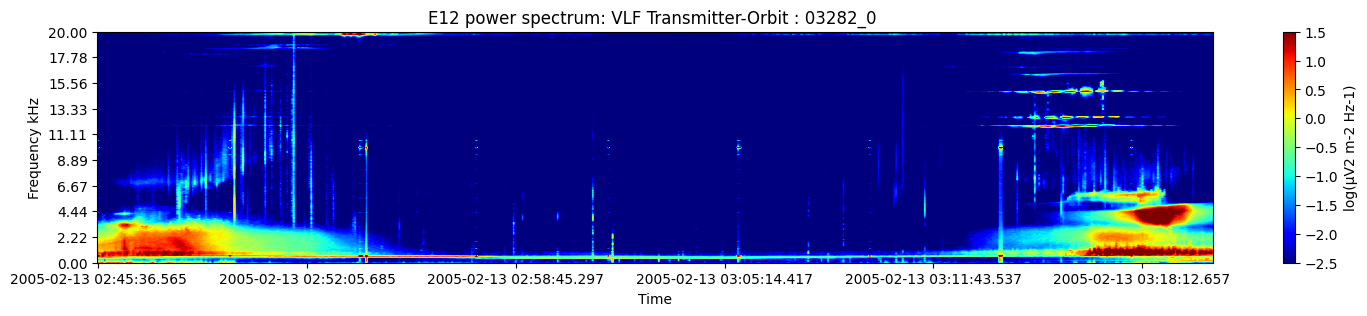

(508, 1024)

In [17]:

import numpy as  np
import pandas as pd
import os
import matplotlib.pyplot as plt
import scipy as sp
from tqdm import tqdm

# data1 = pd.read_pickle('F:\\ASCII_1132\\28-02-2010.pkl')
sp_01 =data['spectrum1'].values
sp_01 = np.array([np.array(x) for x in sp_01])
sp_01 = sp_01.astype(float)
sp_0 =data['spectrum0'].values
sp_0 = np.array([np.array(x) for x in sp_0])
sp_0 = sp_0.astype(float)



# min_freq = 19.035
# max_freq = 18000
#freq_list = np.logspace(np.log10(min_freq), np.log10(max_freq),sp_0.shape[0])
min_freq = 0
max_freq = 20
# Generate a list of frequencies using numpy
freq_list = np.linspace(min_freq, max_freq,10)
freq_list = ["%.2f" % z for z in freq_list]

fig, ax = plt.subplots(figsize=(18,3))
im = ax.imshow(sp_01.T, origin='lower', aspect='auto', cmap='jet',vmax= 1.5, vmin = -2.5)
im = ax.imshow(sp_0.T, origin='lower', aspect='auto', cmap='jet',vmax= 1.5, vmin = -2.5)
ax.set_yticks(np.linspace(0, 1024, 10),freq_list)

datetime1 = data['datetime']
xticks1 = list(range(0, 513, 95))
ax.set_xticks(xticks1, datetime1[xticks1])
# ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# Add colorbar
cbar = fig.colorbar(im)
cbar.set_label('log(μV2 m-2 Hz-1)')
# plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
#ax.set_yticks(range(1024), )
# Set the axis labels
plt.title(f'E12 power spectrum: VLF Transmitter-Orbit : 03282_0 ')
ax.set_xlabel('Time')
ax.set_ylabel('Frequency kHz')
#print(sp_0,freq_index)
# Show the plot
plt.show()




sp_01.shape

SPECTURM CHECK FROM DATA DISCRIPTION OF DEMETER

In [35]:
fn = 'DMT_N1_1137_032320_20050209_162037_20050209_165454.DAT'
input_file ="E:\IMSC-DAT\IMSC-2005\DMT_N1_1137_032320_20050209_162037_20050209_165454.DAT"
data = getdata(input_file)

<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_4608\17624085.py:2: SyntaxWarning: invalid escape sequence '\I'
  input_file ="E:\IMSC-DAT\IMSC-2005\DMT_N1_1137_032320_20050209_162037_20050209_165454.DAT"


In [36]:
orbit = fn.split('_')[3]

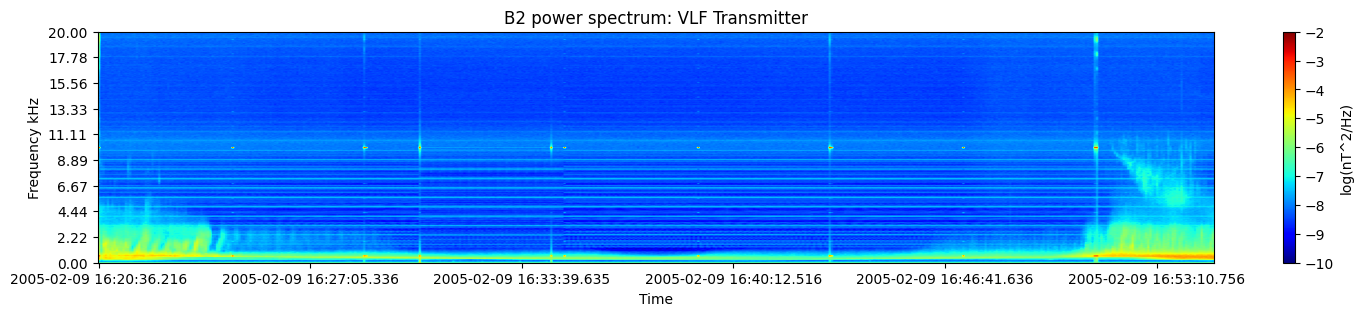

(501, 1024)

In [39]:


# data1 = pd.read_pickle('F:\\ASCII_1132\\28-02-2010.pkl')
sp_01 =data['spectrum1'].values
sp_01 = np.array([np.array(x) for x in sp_01])
sp_01 = sp_01.astype(float)
sp_0 =data['spectrum0'].values
sp_0 = np.array([np.array(x) for x in sp_0])
sp_0 = sp_0.astype(float)



# min_freq = 19.035
# max_freq = 18000
#freq_list = np.logspace(np.log10(min_freq), np.log10(max_freq),sp_0.shape[0])
min_freq = 0
max_freq = 20
# Generate a list of frequencies using numpy
freq_list = np.linspace(min_freq, max_freq,10)
freq_list = ["%.2f" % z for z in freq_list]

fig, ax = plt.subplots(figsize=(18,3))
im = ax.imshow(sp_01.T, origin='lower', aspect='auto', cmap='jet',vmax= -2, vmin = -10)
im = ax.imshow(sp_0.T, origin='lower', aspect='auto', cmap='jet',vmax=-2, vmin = -10)
ax.set_yticks(np.linspace(0, 1024, 10),freq_list)

datetime1 = data['datetime']
xticks1 = list(range(0, 508, 95))
ax.set_xticks(xticks1, datetime1[xticks1])
# ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# Add colorbar
cbar = fig.colorbar(im)
cbar.set_label('log(nT^2/Hz)')
# plt.gca().yaxis.set_major_locator(plt.MaxNLocator(3))
#ax.set_yticks(range(1024), )
# Set the axis labels
plt.title('B2 power spectrum: VLF Transmitter')
ax.set_xlabel('Time')
ax.set_ylabel('Frequency kHz')
#print(sp_0,freq_index)
# Show the plot
plt.show()




sp_01.shape

Zoomed PLots

In [42]:
def plot(df,orbit):


    # Assuming df, sp0, sp1, and lt are defined previously

    sp0 = np.array([np.array(x) for x in df['spectrum0']]).astype(float)
    sp1 = np.array([np.array(x) for x in df['spectrum1']]).astype(float)
    sp = np.empty((sp0.shape[0], sp0.shape[1]*2))
    for i in range(sp0.shape[0]):
        sp[i] = np.concatenate((sp0[i], sp1[i]))
    sp = sp.reshape((sp0.shape[0]*2, 1024))    
    lt = df['datetime']

    lt = df['datetime']
    x = sp0.shape[0]

    # Define the frequency range
    min_freq = 0.0
    max_freq = 20.0
    min_freq_range = 0.00
    max_freq_range = 1.5

    # Calculate the indices corresponding to the frequency range
    start_index = int(min_freq_range / (max_freq / 1024))
    end_index = int(max_freq_range / (max_freq / 1024))

    # Extract the data within the frequency range
    sp_range = sp[:, start_index:end_index]
    num_y_ticks = 6
    freq_list = np.linspace(min_freq_range, max_freq_range, num_y_ticks)
    y_ticks = np.linspace(0, sp_range.shape[1], num_y_ticks)
    # Define x ticks
    x_ticks = list(range(0, 2 * x, 90))
    x_labels = [lt[int(tick / 2)] for tick in x_ticks]

    # Plot the frequency range
    fig, ax1 = plt.subplots(figsize=(18, 6))
    # fig, ax1 = plt.subplots(figsize=(18, 6))
    plt.subplots_adjust(bottom=0.5, top=0.8)
    im = ax1.imshow(sp_range.T, origin='lower', aspect='auto', cmap='jet',vmax=-4.6, vmin = -8.9)

    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels(x_labels, rotation=30, ha='right')
    ax1.set_yticks(y_ticks)
    ax1.set_yticklabels([f'{freq:.2f}' for freq in freq_list])
    ax1.set_xlabel('UT')
    ax1.set_ylabel('Frequency kHz')

    # Add latitude values as the second x-axis
    ax2 = ax1.twiny()
    latitude_values = df['geo_lat'].astype(float)
    x_ticks2_indices = np.linspace(0, len(latitude_values) - 1, 10, dtype=int)
    x_ticks2 = [latitude_values[index] for index in x_ticks2_indices]
    ax2.set_xticks(x_ticks2_indices)
    ax2.set_xticklabels(["%.2f" % lat for lat in x_ticks2], rotation=30, ha='left')
    ax2.set_xlabel('Latitude')
    plt.title('B2 power spectrum ORBIT -{}'.format(orbit))

    cbar = fig.colorbar(im)
    cbar.set_label('log(nT^2 . Hz^-1)')
 


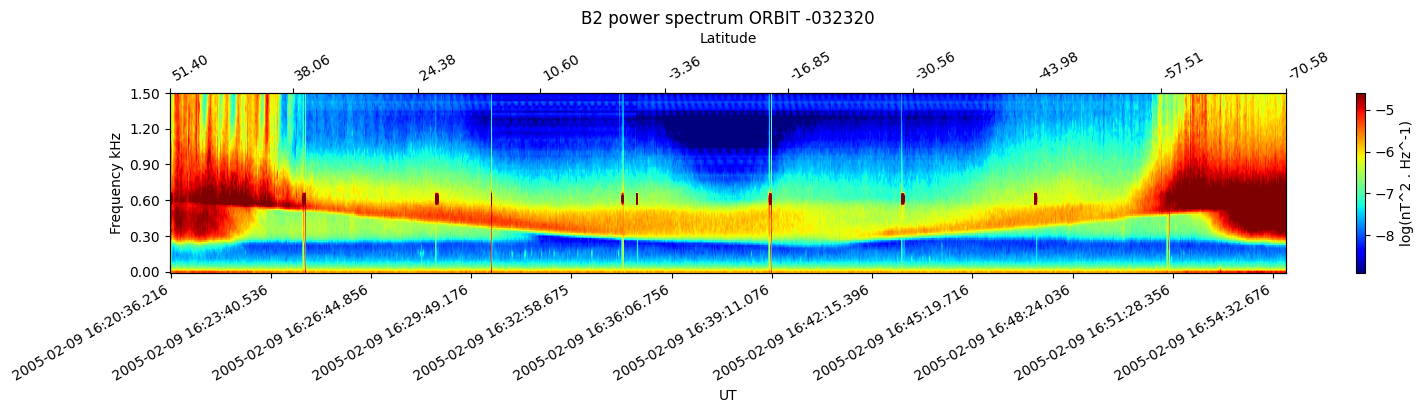

In [43]:
plot(data,orbit)